# 4. Regressão

Prever o resultado geral da unidade com XGBoost, com hiperparâmetros escolhidos por grid search.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid')
SEMENTE = 20262

# a base com as features do caderno 2 e as categóricas já codificadas lá
df = pd.read_csv('../saidas/unidades_features.csv')

# notas dos quatro indicadores, as seis features criadas, familia e distrito em one-hot,
# tipo em label encoding e o nível do tipo como ordinal. nada disso usa o resultado geral
X = df.drop(columns=['tipo', 'geral', 'abaixo_90'], errors='ignore')
y = df['geral']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=SEMENTE)
print(X_treino.shape, X_teste.shape)

(142, 26) (48, 26)


## Grid search

In [2]:
grade = {
    'n_estimators': [100, 300, 500],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
}

busca = GridSearchCV(
    XGBRegressor(random_state=SEMENTE),
    grade,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEMENTE),
    scoring='neg_mean_absolute_error',
    n_jobs=1,
)
busca.fit(X_treino, y_treino)
modelo = busca.best_estimator_

print('melhores parâmetros:', busca.best_params_)
print('MAE na validação cruzada:', round(-busca.best_score_, 4))

melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 500, 'subsample': 0.8}
MAE na validação cruzada: 0.0029


## Resultados no teste

Como referência, comparamos com prever sempre a média do treino.

In [3]:
previsto = modelo.predict(X_teste)
referencia = np.full(len(y_teste), y_treino.mean())

pd.DataFrame({
    'XGBoost': [mean_absolute_error(y_teste, previsto), np.sqrt(mean_squared_error(y_teste, previsto)), r2_score(y_teste, previsto)],
    'média do treino': [mean_absolute_error(y_teste, referencia), np.sqrt(mean_squared_error(y_teste, referencia)), r2_score(y_teste, referencia)],
}, index=['MAE', 'RMSE', 'R²']).round(4)

,XGBoost,média do treino
MAE,0.0044,0.0701
RMSE,0.0144,0.1145
R²,0.9841,-0.0048


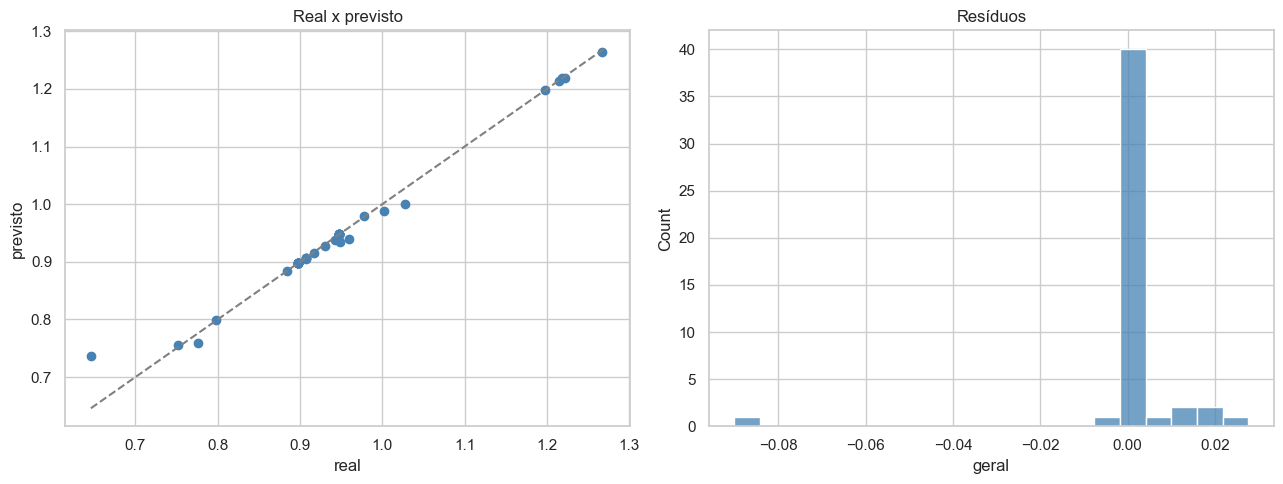

In [4]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5))

eixos[0].scatter(y_teste, previsto, color='steelblue')
limites = [y.min(), y.max()]
eixos[0].plot(limites, limites, color='gray', linestyle='--')
eixos[0].set_xlabel('real')
eixos[0].set_ylabel('previsto')
eixos[0].set_title('Real x previsto')

sns.histplot(y_teste - previsto, bins=20, ax=eixos[1], color='steelblue')
eixos[1].set_title('Resíduos')
plt.tight_layout()
plt.show()

## Importância das features

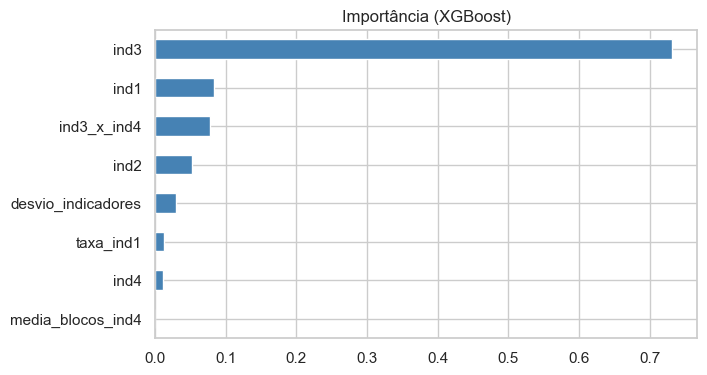

In [5]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
importancias.sort_values().plot.barh(figsize=(7, 4), color='steelblue')
plt.title('Importância (XGBoost)')
plt.show()

O erro fica muito baixo porque o resultado geral é uma soma ponderada das notas dos indicadores. O modelo serve para mostrar quais indicadores mais movem o resultado, não para substituir o cálculo da portaria.

## Salvando o resultado

In [6]:
nomes = {'ind1': 'indicador 1: medicamentos e MMH', 'ind2': 'indicador 2: gestão do trabalho',
         'ind3': 'indicador 3: satisfação do usuário', 'ind4': 'indicador 4: desempenho da unidade',
         'taxa_ind1': 'taxa de atendimento do indicador 1', 'ind3_x_ind4': 'indicador 3 x indicador 4',
         'ind3_abaixo_meta': 'indicador 3 abaixo da meta', 'indicadores_na_meta': 'indicadores na meta',
         'desvio_indicadores': 'desvio entre os indicadores', 'media_blocos_ind4': 'média dos blocos do indicador 4',
         'tipo_codigo': 'tipo de unidade', 'nivel_tipo': 'nível do tipo'}

def nome_legivel(coluna):
    return nomes.get(coluna, coluna.replace('familia_', 'tipo ').replace('distrito_', 'distrito '))

pd.DataFrame({'real': y_teste, 'previsto': previsto}).to_csv('../saidas/previsoes_regressao.csv', index=False)

resultado = {
    'modelo': 'regressao',
    'pergunta': 'Qual resultado geral esperar a partir das notas dos indicadores?',
    'metodo': f"XGBoost com hiperparâmetros por grid search ({busca.best_params_['n_estimators']} árvores, profundidade {busca.best_params_['max_depth']}). Validação cruzada em 5 partes e separação de 75% e 25%.",
    'metricas': {
        'mae': round(float(mean_absolute_error(y_teste, previsto)), 4),
        'r2': round(float(r2_score(y_teste, previsto)), 3),
        'amostras_teste': int(len(y_teste)),
        'importancias': [{'atributo': nome_legivel(c), 'peso': round(float(p), 3)} for c, p in importancias.items()],
    },
    'referencia': {'nome': 'média do treino', 'mae': round(float(mean_absolute_error(y_teste, referencia)), 4)},
    'limitacao': 'O resultado geral é uma soma ponderada das mesmas notas, por isso o erro é tão baixo. O modelo mostra o que mais pesa, não substitui o cálculo.',
}

with open('../saidas/regressao.json', 'w', encoding='utf-8') as arquivo:
    json.dump(resultado, arquivo, ensure_ascii=False, indent=2)